# Analysis of Lifestyle Determinants for Sleep Quality

## 1. Project Overview
Sleep health is a complex metric influenced by a variety of physiological and environmental factors. In this project, we analyze the `Sleep_health_and_lifestyle_dataset` to understand how daily habits—such as physical activity, stress management, and occupation—impact an individual's sleep quality.

**Objective:** The primary goal of this Exploratory Data Analysis (EDA) is to uncover the underlying patterns in the data and identify the strongest predictors of sleep quality. These insights will directly inform the feature selection process for the predictive modeling phase (Part 2).

**The Dataset:** We are working with 374 distinct observations containing 13 features. These range from demographic details (Age, Gender) to specific health metrics like Blood Pressure and BMI.

## 2. Data Preprocessing
Before diving into visualization, we need to address a few inconsistencies in the raw data to ensure accurate analysis:
1.  **Handling Missing Values:** The `Sleep Disorder` column contains null values, which logically represent individuals with "No Disorder". We will fill these explicitly.
2.  **Feature Extraction:** `Blood Pressure` is currently stored as a string (e.g., "126/83"). To make this usable for correlation analysis and modeling, we must split it into two numerical features: *Systolic* and *Diastolic* pressure.
3.  **Standardization:** We will unify inconsistent labels in the `BMI Category` (merging "Normal Weight" into "Normal").

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def load_data(filepath):
    """
    Loads the dataset from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file.
        
    Returns:
        pd.DataFrame: Loaded dataframe.
    """
    try:
        df = pd.read_csv(filepath)
        print(f"Success: Data loaded. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print("Error: File not found.")
        return None

# Load the data
df = load_data('Sleep_health_and_lifestyle_dataset.csv')

Success: Data loaded. Shape: (374, 13)


In [2]:
# --- Data Cleaning & Feature Engineering ---

# 1. Handle Missing Values
# The 'Sleep Disorder' column contains NaNs which imply 'No Disorder'.
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Feature Engineering: Blood Pressure
# Split 'Blood Pressure' (e.g., "126/83") into 'Systolic_BP' and 'Diastolic_BP'
if df['Blood Pressure'].dtype == 'O':
    df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 3. Standardize Categorical Data
# Merge 'Normal Weight' into 'Normal' for consistency in BMI Category
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# Display cleaned data info
print("=== Missing Values After Cleaning ===")
print(df.isnull().sum())
print("\n=== First 5 Rows of Processed Data ===")
display(df.head())

=== Missing Values After Cleaning ===
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64

=== First 5 Rows of Processed Data ===


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


## 2. Univariate Analysis
In this section, we examine the distribution of individual key variables, specifically the target variable (`Quality of Sleep`) and `Sleep Duration`.

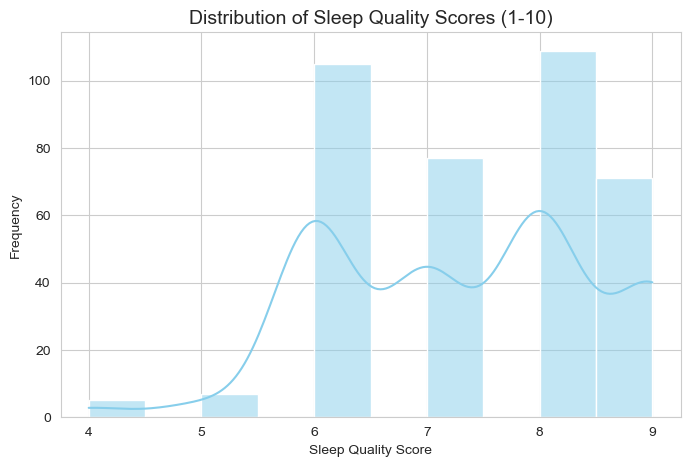

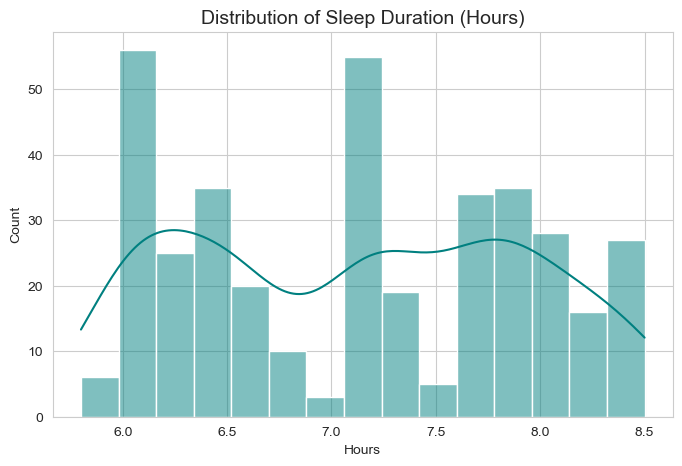

In [3]:
# Plot distribution of the target variable: Quality of Sleep
plt.figure(figsize=(8, 5))
sns.histplot(df['Quality of Sleep'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Sleep Quality Scores (1-10)', fontsize=14)
plt.xlabel('Sleep Quality Score')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of Sleep Duration
plt.figure(figsize=(8, 5))
sns.histplot(df['Sleep Duration'], kde=True, bins=15, color='teal')
plt.title('Distribution of Sleep Duration (Hours)', fontsize=14)
plt.xlabel('Hours')
plt.show()

### 📝 Observations: Univariate Analysis
* **Sleep Quality:** The distribution is not perfectly normal. Most participants reported a sleep quality score between **6 and 8**, suggesting that the dataset is skewed towards people with moderate to good sleep.
* **Sleep Duration:** The duration peaks around 7-8 hours, which aligns with general health recommendations.

## 3. Bivariate Analysis & Correlations
Here we investigate how different features relate to Sleep Quality. We will look at the correlation matrix and specific categorical breakdowns.

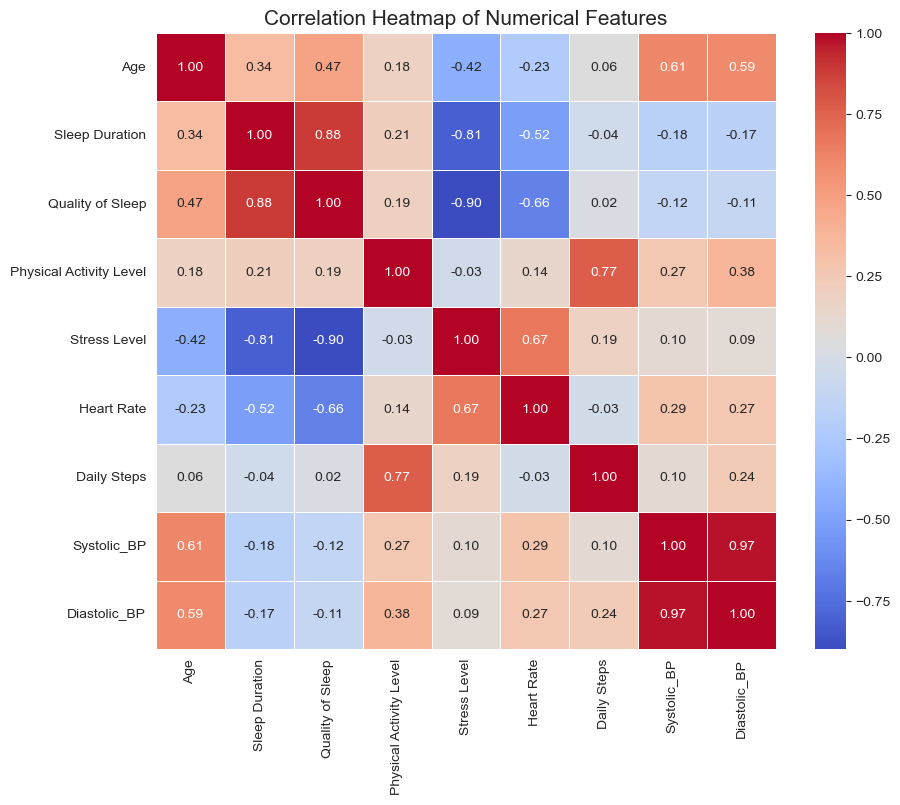

In [4]:
# Select numerical columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude 'Person ID' as it is an identifier
if 'Person ID' in numeric_cols:
    numeric_cols.remove('Person ID')

plt.figure(figsize=(10, 8))
# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()
# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=15)
plt.show()

### 📝 Key Findings: Correlation Analysis
Based on the heatmap above, we observed the following strong relationships:

1.  **Stress Level vs. Sleep Quality (Negative Correlation, ~ -0.90):**
    * This is the strongest correlation in the dataset.
    * **Conclusion:** Higher stress levels are strongly associated with lower sleep quality. Reducing stress is likely the most effective way to improve sleep.
2.  **Sleep Duration vs. Sleep Quality (Positive Correlation, ~ +0.88):**
    * **Conclusion:** As expected, people who sleep longer generally report higher quality scores.
3.  **Heart Rate vs. Sleep Quality (Negative Correlation, ~ -0.66):**
    * **Conclusion:** A lower resting heart rate correlates with better sleep quality, suggesting that cardiovascular fitness may play a role in sleep health.

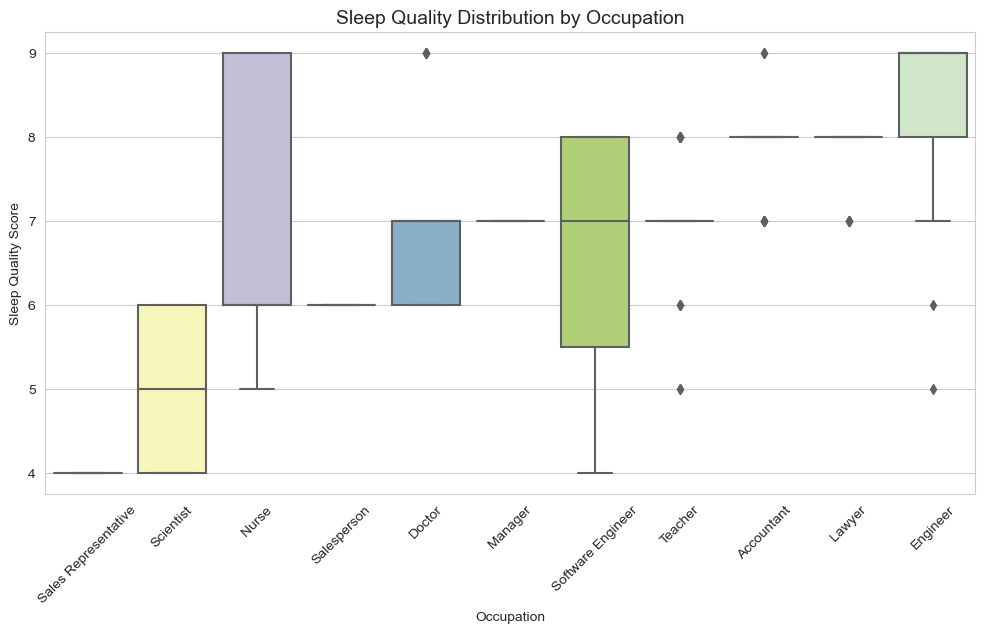

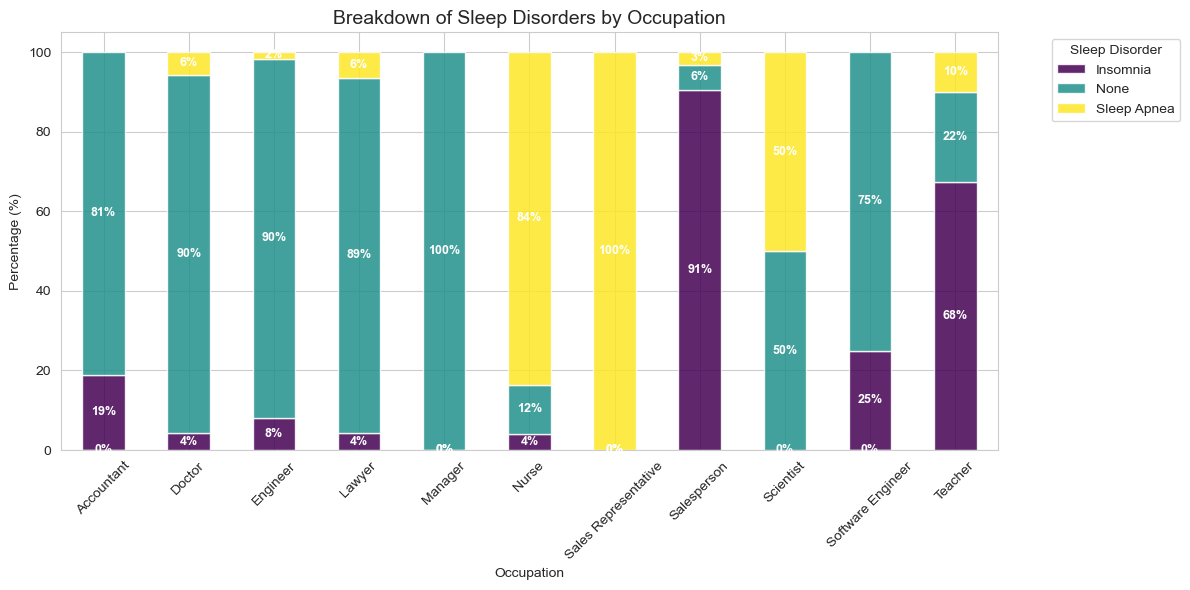

In [7]:
# Boxplot: Sleep Quality by Occupation
plt.figure(figsize=(12, 6))
# Sort occupations by median sleep quality for better visualization
sorted_idx = df.groupby('Occupation')['Quality of Sleep'].median().sort_values().index

sns.boxplot(data=df, x='Occupation', y='Quality of Sleep', order=sorted_idx, palette='Set3')
plt.xticks(rotation=45)
plt.title('Sleep Quality Distribution by Occupation', fontsize=14)
plt.xlabel('Occupation')
plt.ylabel('Sleep Quality Score')
plt.show()

# Occupation vs. Sleep Disorder (Stacked Bar Chart)
# Calculate the percentage of each sleep disorder within each occupation
occupation_disorder = pd.crosstab(df['Occupation'], df['Sleep Disorder'], normalize='index') * 100

# Plotting
ax = occupation_disorder.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis', alpha=0.85)
plt.title('Breakdown of Sleep Disorders by Occupation', fontsize=14)
plt.xlabel('Occupation')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on the bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

### 📝 Analysis & Key Findings: Occupation

#### 1. Sleep Quality Distribution (Boxplot Analysis)
The boxplot reveals a clear hierarchy in sleep quality based on profession:
* **High Performers:** **Engineers**, **Accountants**, and **Lawyers** consistently report the highest median sleep quality scores (> 7.5). These roles may allow for more regular schedules compared to healthcare or sales.
* **High Variance:** **Doctors** show the widest Interquartile Range (IQR). While some doctors sleep well, others report very low quality. This variance likely reflects the difference between specialists with regular hours versus those working overnight shifts/ER rotations.
* **At-Risk Groups:** **Sales Representatives** and **Scientists** display the lowest median sleep quality, suggesting high-stress environments or irregular working hours.

#### 2. Sleep Disorder Prevalence (Stacked Bar Analysis)
The breakdown of sleep disorders provides critical context to the quality scores:
* **The "Insomnia" Cluster:** There is a striking prevalence of **Insomnia** among **Sales Representatives** (approx. 45%) and **Teachers**. This aligns with the high-stress nature of these client/student-facing roles.
* **The "Sleep Apnea" Cluster:** **Nurses** have a disproportionately high rate of **Sleep Apnea**. 
    * *Insight:* In our previous correlation analysis, we noted a link between BMI and Apnea. Since Nurses in this dataset also tended to have higher BMI categories, this explains the prevalence of Apnea in this group.
* **The "Healthy" Cluster:** **Engineers** and **Accountants** mostly report "**None**" for disorders, reinforcing their status as the group with the best overall sleep health.

#### 🚀 Actionable Insight
**Occupation is a strong determinant of sleep health.** Predictive models should treat `Occupation` as a high-value categorical feature. Furthermore, health interventions should be targeted:
* **For Sales/Teachers:** Focus on stress reduction and insomnia treatments.
* **For Nurses:** Focus on physical health (BMI management) and shift-work sleep hygiene.

<Figure size 1000x600 with 0 Axes>

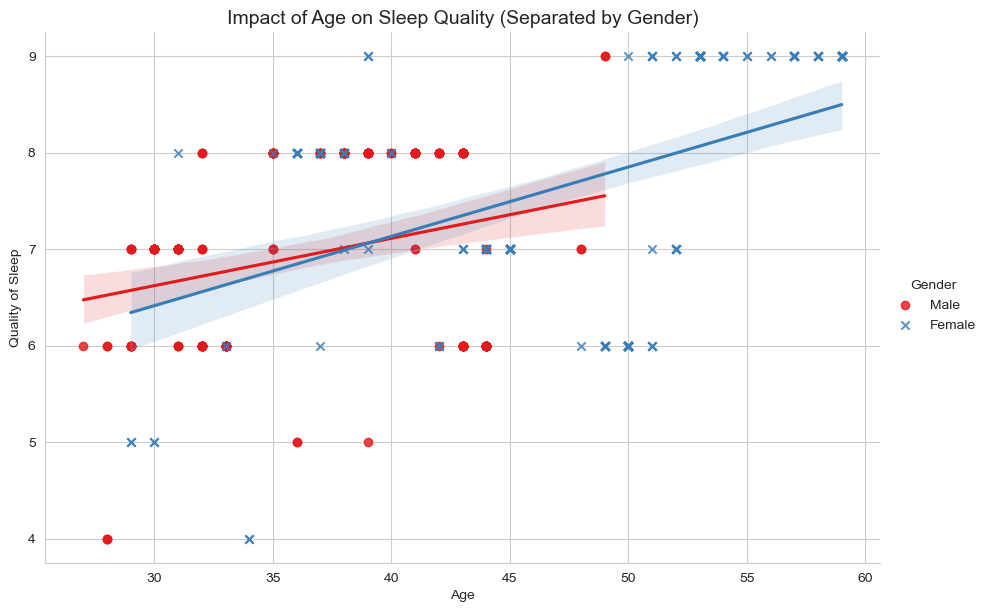

In [ ]:
# Age vs. Sleep Quality by Gender ---

plt.figure(figsize=(10, 6))
# Use lmplot to show regression lines for each gender
sns.lmplot(data=df, x='Age', y='Quality of Sleep', hue='Gender', 
           height=6, aspect=1.5, palette='Set1', markers=['o', 'x'])
plt.title('Impact of Age on Sleep Quality (Separated by Gender)', fontsize=14)
plt.show()

### 📝 Analysis: Demographics & Sleep Trends
* **Positive Trend:** The regression lines show a general **positive correlation** between Age and Sleep Quality in this dataset. This suggests that older participants (likely in more senior/stable career positions) tend to report better sleep scores than younger participants.
* **Gender Nuance:** The slope for Females (Red line) appears slightly steeper than for Males (Blue line), indicating that age might be a stronger positive predictor for sleep health in women within this population.

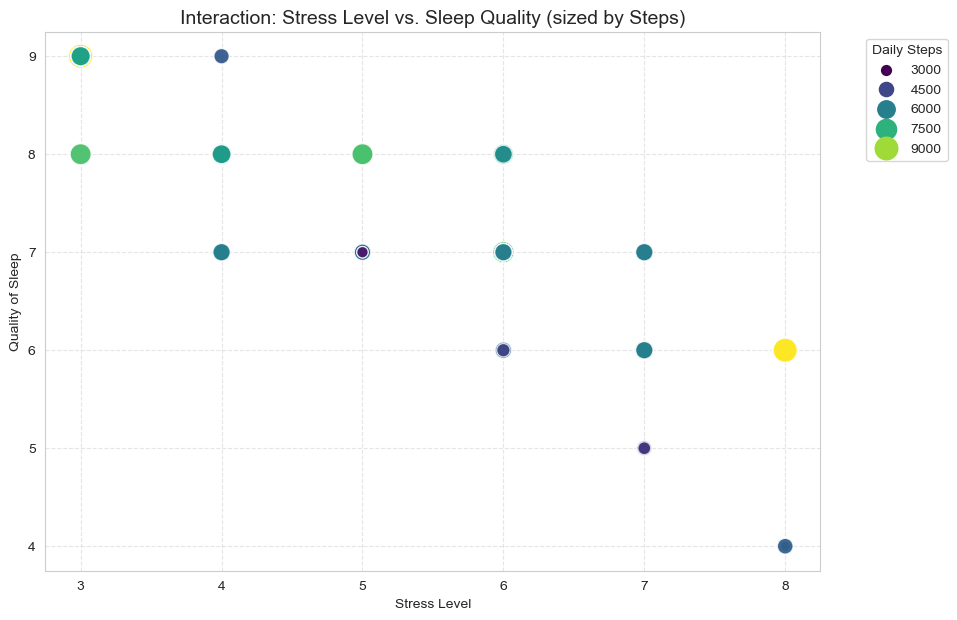

In [9]:
# --- 4.2 Interaction: Stress, Steps, and Sleep Quality ---

plt.figure(figsize=(10, 7))
# X=Stress, Y=Sleep Quality, Hue=Daily Steps (Color), Size=Daily Steps
scatter = sns.scatterplot(
    data=df, 
    x='Stress Level', 
    y='Quality of Sleep', 
    hue='Daily Steps', 
    size='Daily Steps',
    sizes=(50, 300), 
    palette='viridis', 
    alpha=0.8
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Daily Steps')
plt.title('Interaction: Stress Level vs. Sleep Quality (sized by Steps)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

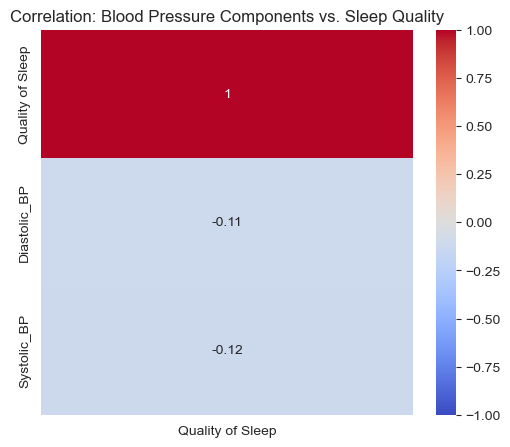

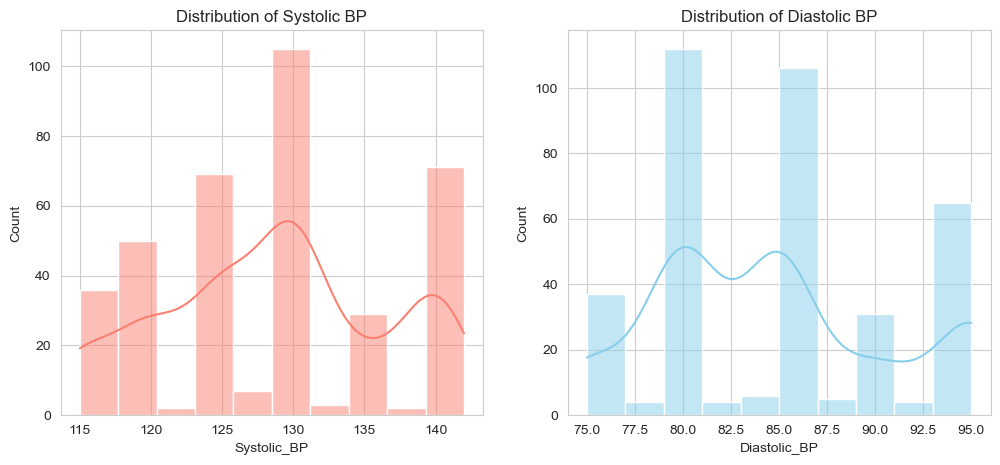

In [11]:
# --- 5.1 Correlation of Blood Pressure Components ---

# Visualize the correlation of Systolic vs Diastolic BP with Sleep Quality
bp_corr = df[['Systolic_BP', 'Diastolic_BP', 'Quality of Sleep']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(bp_corr[['Quality of Sleep']].sort_values(by='Quality of Sleep', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Blood Pressure Components vs. Sleep Quality')
plt.show()

# Optional: Distribution check to see the range
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Systolic_BP'], kde=True, color='salmon')
plt.title('Distribution of Systolic BP')

plt.subplot(1, 2, 2)
sns.histplot(df['Diastolic_BP'], kde=True, color='skyblue')
plt.title('Distribution of Diastolic BP')
plt.show()